# Multiple Regression

In [37]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Load Data

In [38]:
df = pd.read_csv('../data/50_Startups.csv')
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.5 KB


### Define X and y

In [40]:
X = df[['R&D Spend', 'Administration', 'Marketing Spend', 'State']]
y = df['Profit']

### Train test split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = 42)

### Preprocessing

In [44]:
cat_features = ['State']
num_features = ['R&D Spend', 'Administration', 'Marketing Spend']

preprocessor = ColumnTransformer(
    transformers = [('state_encoder', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)],
    remainder='passthrough',
    force_int_remainder_cols=False)

### Build linear regression pipeline

In [45]:
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

### Train the model

In [46]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('state_encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['State'])])),
                ('model', LinearRegression())])

### Make predictions

In [47]:
y_pred = linear_model.predict(X_test)

In [48]:
y_pred

array([126362.87908252,  84608.45383643,  99677.49425155,  46357.46068582,
       128750.48288497,  50912.41741905, 109741.350327  , 100643.24281644,
        97599.275746  , 113097.42524437])

### Evaluate model performance

In [50]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("-----------------")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.4f}")

Model Performance
-----------------
MAE:  6961.48
RMSE: 9055.96
R2:   0.8987


### Compare actual vs predicted values

In [51]:
results = pd.DataFrame({
    "Actual Profit": y_test.values,
    "Predicted Profit": y_pred,
    "Error": y_test.values - y_pred
})

print("\nActual vs Predicted")
print(results)


Actual vs Predicted
   Actual Profit  Predicted Profit         Error
0      134307.35     126362.879083   7944.470917
1       81005.76      84608.453836  -3602.693836
2       99937.59      99677.494252    260.095748
3       64926.08      46357.460686  18568.619314
4      125370.37     128750.482885  -3380.112885
5       35673.41      50912.417419 -15239.007419
6      105733.54     109741.350327  -4007.810327
7      107404.34     100643.242816   6761.097184
8       97427.84      97599.275746   -171.435746
9      122776.86     113097.425244   9679.434756


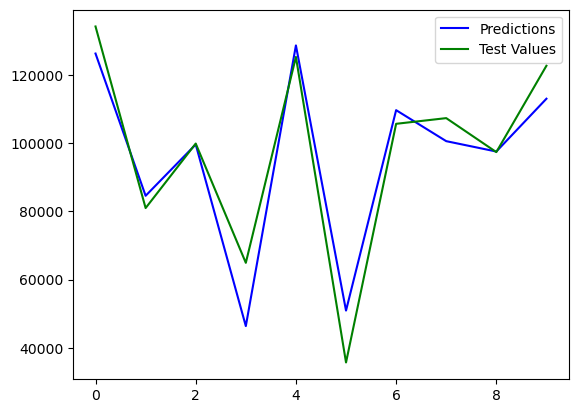

In [59]:
plt.plot(y_pred, color='blue', label='Predictions')
plt.plot(y_test.values, color='green', label='Test Values')
plt.legend()
plt.show()

### Extract model coefficients

In [53]:
# Get encoded State feature names
encoded_state_features = linear_model.named_steps["preprocessor"] \
    .named_transformers_["state_encoder"] \
    .get_feature_names_out(cat_features)

In [55]:
# Combine encoded State names with numeric feature names
feature_names = list(encoded_state_features) + num_features

coefficients = linear_model.named_steps["model"].coef_

coef_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [56]:
intercept = linear_model.named_steps["model"].intercept_

print("\nIntercept:")
print(intercept)

print("\nCoefficients:")
print(coef_table)


Intercept:
54028.03959405856

Coefficients:
           Feature  Coefficient
0    State_Florida   938.793006
1   State_New York     6.987760
2        R&D Spend     0.805630
3   Administration    -0.068788
4  Marketing Spend     0.029855


### Make out of sample prediction

In [62]:
new_business = pd.DataFrame({
    "R&D Spend": [160000],
    "Administration": [130000],
    "Marketing Spend": [300000],
    "State": ["California"]
})

predicted_profit = linear_model.predict(new_business)

print(f"Predicted Profit: ${predicted_profit[0]:,.2f}")

Predicted Profit: $182,943.06
